# E-Commerce Revenue Structure & Customer Retention Analysis

## Business-Oriented Data Analysis Project


## 1. Introduction

The objective of this analysis is to evaluate the revenue structure of the company, understand customer purchasing behavior, and identify potential structural risks within the business model.

This project moves beyond descriptive metrics and focuses on connecting data insights with strategic business decisions.

### Key Questions

- How concentrated is revenue across product categories?
- What is the purchasing behavior per order?
- How dependent is the company on recurrent customers?
- Is there a structural revenue concentration risk?
- What strategic actions could improve long-term sustainability?


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')


In [2]:
from google.colab import files
uploaded = files.upload()


Saving olist_customers_dataset.csv to olist_customers_dataset.csv
Saving olist_geolocation_dataset.csv to olist_geolocation_dataset.csv
Saving olist_order_items_dataset.csv to olist_order_items_dataset.csv
Saving olist_order_payments_dataset.csv to olist_order_payments_dataset.csv
Saving olist_order_reviews_dataset.csv to olist_order_reviews_dataset.csv
Saving olist_orders_dataset.csv to olist_orders_dataset.csv
Saving olist_products_dataset.csv to olist_products_dataset.csv
Saving olist_sellers_dataset.csv to olist_sellers_dataset.csv
Saving product_category_name_translation.csv to product_category_name_translation.csv


In [3]:
# ==============================
# 1. IMPORT LIBRARIES
# ==============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")


In [4]:
# ==============================
# 2. LOAD DATA
# ==============================

orders = pd.read_csv("olist_orders_dataset.csv")
order_items = pd.read_csv("olist_order_items_dataset.csv")
products = pd.read_csv("olist_products_dataset.csv")
customers = pd.read_csv("olist_customers_dataset.csv")
category_translation = pd.read_csv("product_category_name_translation.csv")


In [5]:
# Quick check
orders.head()


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [6]:
# ==============================
# 3. DATA MODELING
# ==============================

# Merge orders + order_items
df = orders.merge(order_items, on="order_id", how="inner")

# Merge products
df = df.merge(products, on="product_id", how="left")

# Merge category translation
df = df.merge(category_translation,
              on="product_category_name",
              how="left")

# Merge customers
df = df.merge(customers, on="customer_id", how="left")

df.head()


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,...,4.0,500.0,19.0,8.0,13.0,housewares,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1,595fac2a385ac33a80bd5114aec74eb8,...,1.0,400.0,19.0,13.0,19.0,perfumery,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1,aa4383b373c6aca5d8797843e5594415,...,1.0,420.0,24.0,19.0,21.0,auto,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,1,d0b61bfb1de832b15ba9d266ca96e5b0,...,3.0,450.0,30.0,10.0,20.0,pet_shop,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,1,65266b2da20d04dbe00c5c2d3bb7859e,...,4.0,250.0,51.0,15.0,15.0,stationery,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP


In [7]:
# Convert dates
df["order_purchase_timestamp"] = pd.to_datetime(df["order_purchase_timestamp"])

# Keep only delivered orders
df = df[df["order_status"] == "delivered"]

# Create revenue column
df["revenue"] = df["price"] + df["freight_value"]

df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 110197 entries, 0 to 112649
Data columns (total 28 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       110197 non-null  object        
 1   customer_id                    110197 non-null  object        
 2   order_status                   110197 non-null  object        
 3   order_purchase_timestamp       110197 non-null  datetime64[ns]
 4   order_approved_at              110182 non-null  object        
 5   order_delivered_carrier_date   110195 non-null  object        
 6   order_delivered_customer_date  110189 non-null  object        
 7   order_estimated_delivery_date  110197 non-null  object        
 8   order_item_id                  110197 non-null  int64         
 9   product_id                     110197 non-null  object        
 10  seller_id                      110197 non-null  object        
 11  shipp

In [8]:
orders_per_customer = df.groupby("customer_unique_id")["order_id"].nunique().reset_index()
orders_per_customer.columns = ["customer_unique_id", "total_orders"]

orders_per_customer.head()


,customer_unique_id,total_orders
0,0000366f3b9a7992bf8c76cfdf3221e2,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1
2,0000f46a3911fa3c0805444483337064,1
3,0000f6ccb0745a6a4b88665a16c9f078,1
4,0004aac84e0df4da2b147fca70cf8255,1


In [9]:
revenue_per_customer = df.groupby("customer_unique_id")["revenue"].sum().reset_index()

customer_analysis = orders_per_customer.merge(revenue_per_customer,
                                              on="customer_unique_id")

customer_analysis.head()


,customer_unique_id,total_orders,revenue
0,0000366f3b9a7992bf8c76cfdf3221e2,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19
2,0000f46a3911fa3c0805444483337064,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,1,196.89


In [10]:
repeat_customers = customer_analysis[customer_analysis["total_orders"] > 1]
single_customers = customer_analysis[customer_analysis["total_orders"] == 1]

repeat_percentage = len(repeat_customers) / len(customer_analysis) * 100

print(f"Repeat Customers: {repeat_percentage:.2f}%")


Repeat Customers: 3.00%


In [11]:
repeat_revenue = repeat_customers["revenue"].sum()
total_revenue = customer_analysis["revenue"].sum()

repeat_revenue_percentage = repeat_revenue / total_revenue * 100

print(f"Revenue from Repeat Customers: {repeat_revenue_percentage:.2f}%")


Revenue from Repeat Customers: 5.60%


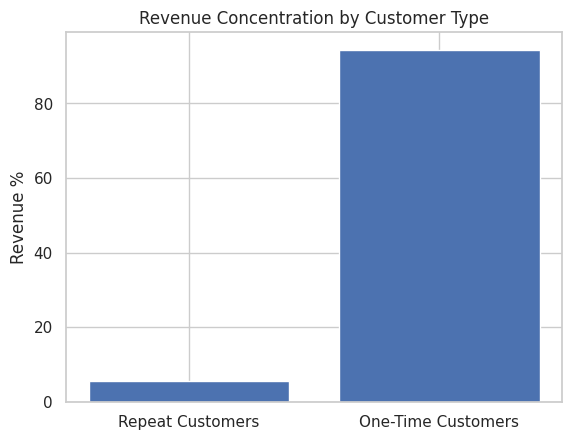

In [12]:
plt.figure()
plt.bar(["Repeat Customers", "One-Time Customers"],
        [repeat_revenue_percentage,
         100 - repeat_revenue_percentage])

plt.title("Revenue Concentration by Customer Type")
plt.ylabel("Revenue %")
plt.show()


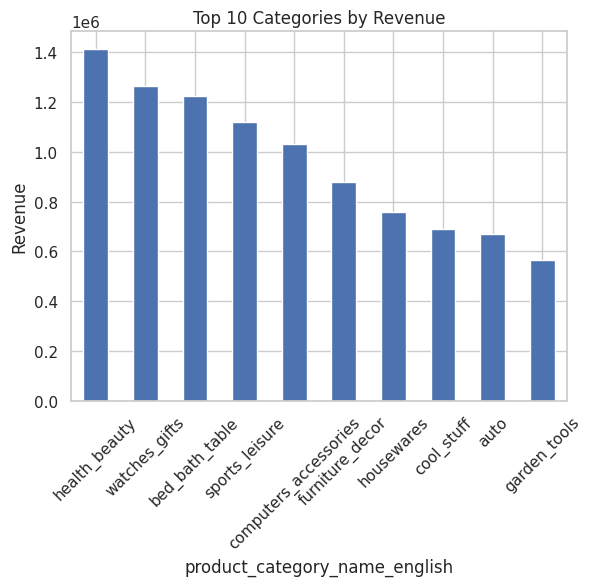

In [13]:
category_revenue = df.groupby("product_category_name_english")["revenue"].sum().sort_values(ascending=False)

top_categories = category_revenue.head(10)

plt.figure()
top_categories.plot(kind="bar")
plt.title("Top 10 Categories by Revenue")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()


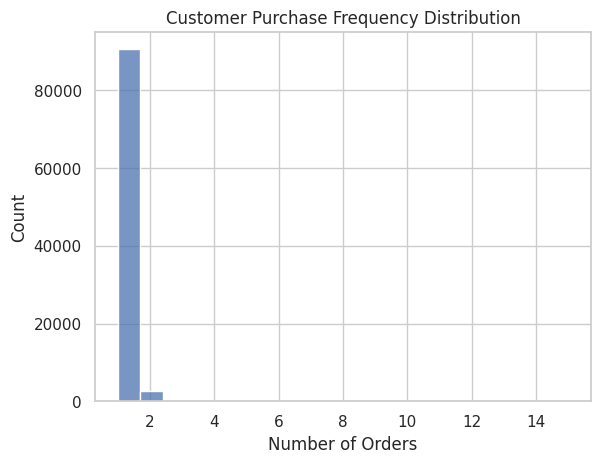

In [14]:
plt.figure()
sns.histplot(customer_analysis["total_orders"], bins=20)
plt.title("Customer Purchase Frequency Distribution")
plt.xlabel("Number of Orders")
plt.show()


In [15]:
# Top 25% revenue customers

customer_analysis = customer_analysis.sort_values("revenue", ascending=False)
customer_analysis["cumulative_revenue"] = customer_analysis["revenue"].cumsum()
customer_analysis["cumulative_percentage"] = (
    customer_analysis["cumulative_revenue"] /
    total_revenue * 100
)

top_25_percent = int(len(customer_analysis) * 0.25)

top_segment = customer_analysis.head(top_25_percent)

segment_revenue_share = top_segment["revenue"].sum() / total_revenue * 100

print(f"Top 25% customers generate {segment_revenue_share:.2f}% of revenue")


Top 25% customers generate 59.43% of revenue


# Business Insights

## 1. Revenue Dependency

If a small percentage of customers generates the majority of revenue,
the company faces structural concentration risk.

This means losing high-value customers would severely impact financial performance.

## 2. Retention Strategy

Given that repeat customers contribute disproportionately to revenue:

- Focus on loyalty programs
- Personalized marketing
- Category-based targeting
- Cross-selling and upselling strategies

## 3. Category Expansion

Top-performing categories should receive:

- Continued investment
- Product innovation
- Competitive defense strategies

At the same time, emerging categories should be developed to reduce risk concentration.

## 4. Strategic Risk

Heavy dependence on a small customer segment creates vulnerability.

Diversification across:
- Categories
- Customer segments
- Product innovation

is critical to long-term sustainability.


# Final Conclusion

This analysis demonstrates that data-driven decision making allows businesses to:

- Identify structural risks
- Understand customer behavior
- Protect high-value segments
- Allocate investment strategically

The key takeaway:

Retention is not just a marketing metric —  
it is a structural pillar of revenue stability.

A company that understands who sustains its revenue
can defend, optimize, and expand intelligently.


# What I Learned

This project reinforced the importance of:

- Connecting data to strategy
- Thinking beyond metrics
- Evaluating structural risk
- Making decisions under uncertainty

Data is not only descriptive — it is strategic.
